# 03 - Baseline Model (24h Forecast Horizon)
LightGBM + Random Forest with quantile uncertainty intervals.
Includes flow temperature lags as proxy for operator intentions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
%matplotlib inline

HORIZON = 24

In [2]:
df = pd.read_csv('../data/processed/demand_with_weather.csv', index_col='timestamp', parse_dates=True)
df = df.dropna(subset=['heat_demand_mw'])
print(f'Loaded {len(df)} rows')

Loaded 43843 rows


In [3]:
# Demand lags
df['demand_lag_25h']   = df['heat_demand_mw'].shift(HORIZON + 1)
df['demand_lag_48h']   = df['heat_demand_mw'].shift(48)
df['demand_lag_168h']  = df['heat_demand_mw'].shift(168)
df['demand_lag_336h']  = df['heat_demand_mw'].shift(336)
df['demand_roll_48h']  = df['heat_demand_mw'].shift(HORIZON + 1).rolling(48).mean()
df['demand_roll_168h'] = df['heat_demand_mw'].shift(HORIZON + 1).rolling(168).mean()

# Flow temperature lags — proxy for operator intentions
df['flow_temp_lag_25h'] = df['flow_temp_c'].shift(HORIZON + 1)
df['flow_temp_lag_48h'] = df['flow_temp_c'].shift(48)

df = df.dropna()
print(f'Rows after lag features: {len(df)}')

Rows after lag features: 43507


In [4]:
FEATURES = [
    'temperature_c', 'heating_degrees', 'temp_change_3h',
    'wind_speed_ms', 'wind_sin', 'wind_cos',
    'solar_radiation_wm2', 'humidity_pct',
    'snowfall_cm', 'snow_depth_m', 'cloud_cover_pct',
    'hour', 'day_of_week', 'day_of_year', 'is_weekend',
    'is_holiday', 'is_school_holiday', 'heating_season_day',
    'demand_lag_25h', 'demand_lag_48h', 'demand_lag_168h', 'demand_lag_336h',
    'demand_roll_48h', 'demand_roll_168h',
    'flow_temp_lag_25h', 'flow_temp_lag_48h'
]
TARGET = 'heat_demand_mw'
print(f'{len(FEATURES)} features')

26 features


In [5]:
train = df[df.index.year < 2024]
test  = df[df.index.year == 2024]
X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]
print(f'Train: {len(train)} | Test: {len(test)}')

Train: 34724 | Test: 8783


In [6]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true.clip(lower=1))) * 100
    print(f'{name}  ->  MAE: {mae:.2f} MW  |  RMSE: {rmse:.2f} MW  |  MAPE: {mape:.1f}%')
    return {'model': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE': round(mape,1)}

BASE = dict(n_estimators=500, learning_rate=0.05, num_leaves=63, n_jobs=-1, random_state=42)

print('Training Random Forest...')
rf = RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_preds = pd.Series(rf.predict(X_test), index=y_test.index)
rf_scores = evaluate('Random Forest', y_test, rf_preds)

print('Training LightGBM median...')
lgb_mid = lgb.LGBMRegressor(objective='quantile', alpha=0.50, **BASE)
lgb_mid.fit(X_train, y_train)
preds_mid = pd.Series(lgb_mid.predict(X_test), index=y_test.index)
lgb_scores = evaluate('LightGBM', y_test, preds_mid)

print('Training lower bound (10th pct)...')
lgb_lo = lgb.LGBMRegressor(objective='quantile', alpha=0.10, **BASE)
lgb_lo.fit(X_train, y_train)
preds_lo = pd.Series(lgb_lo.predict(X_test), index=y_test.index)

print('Training upper bound (90th pct)...')
lgb_hi = lgb.LGBMRegressor(objective='quantile', alpha=0.90, **BASE)
lgb_hi.fit(X_train, y_train)
preds_hi = pd.Series(lgb_hi.predict(X_test), index=y_test.index)

coverage = ((y_test >= preds_lo) & (y_test <= preds_hi)).mean() * 100
avg_width = (preds_hi - preds_lo).mean()
print(f'\n80% interval coverage: {coverage:.1f}% (target: 80%)')
print(f'Average interval width: {avg_width:.1f} MW')

Training Random Forest...
Random Forest  ->  MAE: 9.74 MW  |  RMSE: 14.13 MW  |  MAPE: 8.7%
Training LightGBM median...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001414 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 34724, number of used features: 26
[LightGBM] [Info] Start training from score 119.253494
LightGBM  ->  MAE: 8.75 MW  |  RMSE: 12.86 MW  |  MAPE: 7.8%
Training lower bound (10th pct)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001223 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 34724, number of used features: 26
[LightGBM] [Info] Start

                MAE   RMSE  MAPE
model                           
Random Forest  9.74  14.13   8.7
LightGBM       8.75  12.86   7.8


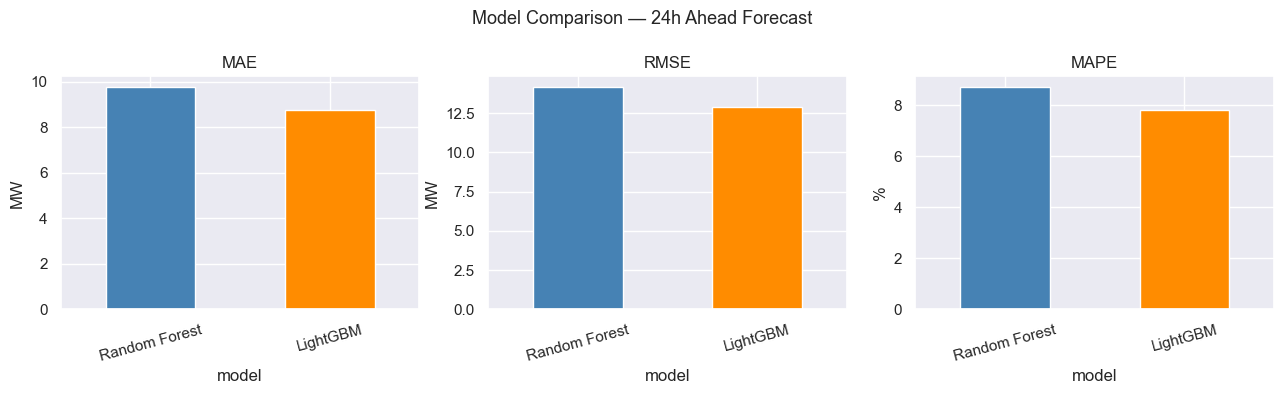

In [7]:
results = pd.DataFrame([rf_scores, lgb_scores]).set_index('model')
print(results.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, metric in enumerate(['MAE', 'RMSE', 'MAPE']):
    results[metric].plot(kind='bar', ax=axes[i], color=['steelblue','darkorange'])
    axes[i].set_title(metric)
    axes[i].set_ylabel('MW' if metric != 'MAPE' else '%')
    axes[i].tick_params(axis='x', rotation=15)
plt.suptitle(f'Model Comparison — {HORIZON}h Ahead Forecast', fontsize=13)
plt.tight_layout()
plt.show()

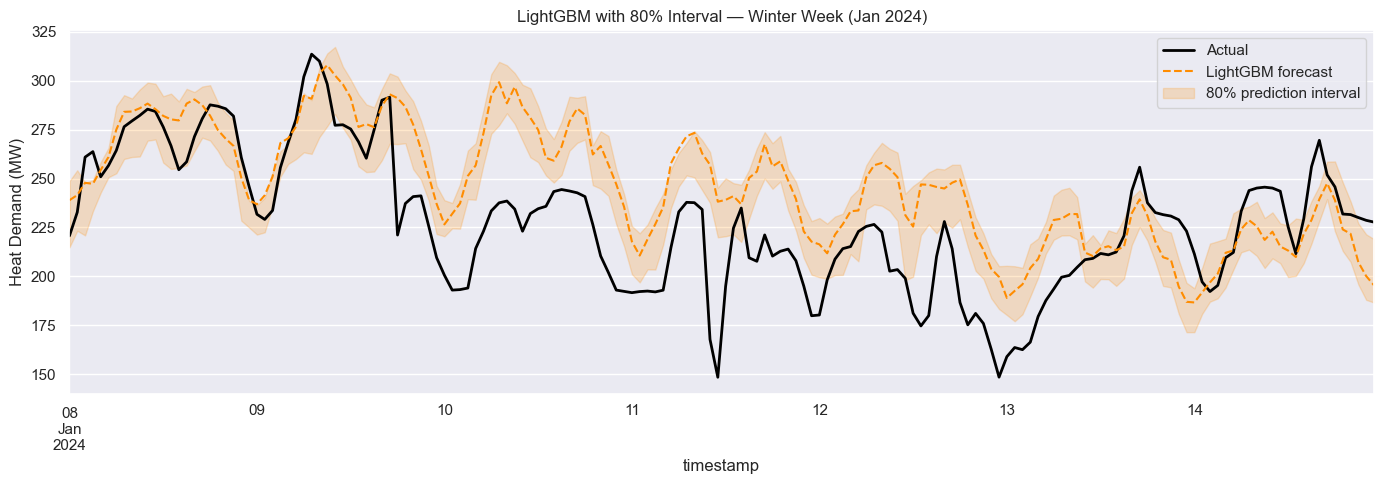

In [8]:
def plot_week(start, title):
    mask = (y_test.index >= start) & (y_test.index < pd.Timestamp(start) + pd.Timedelta(days=7))
    fig, ax = plt.subplots(figsize=(14, 5))
    y_test[mask].plot(ax=ax, label='Actual', linewidth=2, color='black')
    preds_mid[mask].plot(ax=ax, label='LightGBM forecast', linestyle='--', color='darkorange')
    ax.fill_between(
        preds_lo[mask].index,
        preds_lo[mask].values,
        preds_hi[mask].values,
        alpha=0.2, color='darkorange', label='80% prediction interval'
    )
    ax.set_title(title)
    ax.set_ylabel('Heat Demand (MW)')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_week('2024-01-08', 'LightGBM with 80% Interval — Winter Week (Jan 2024)')

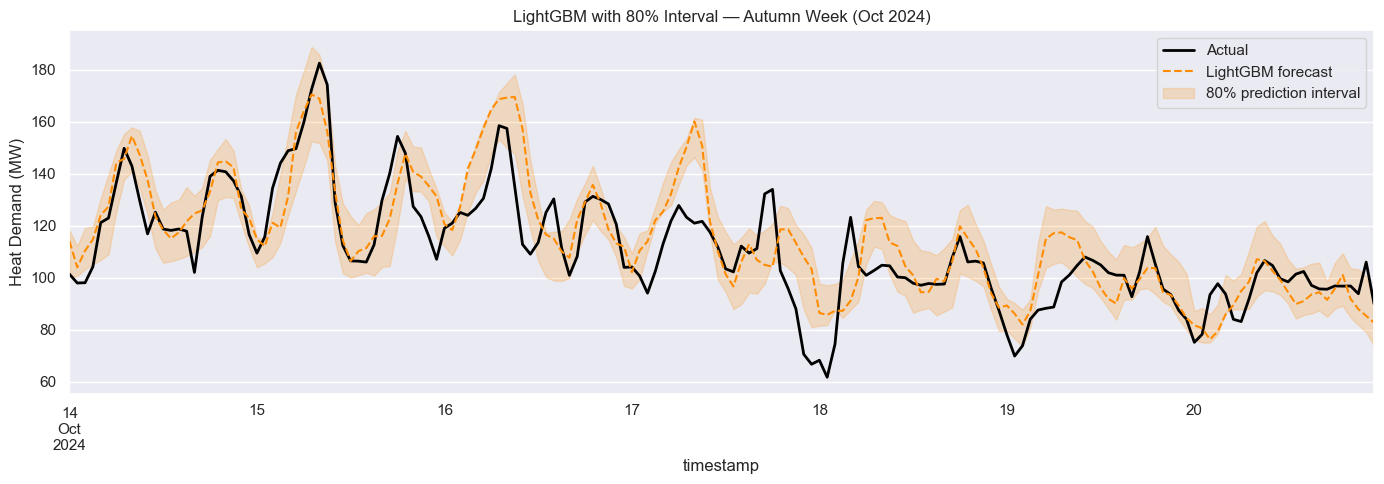

In [9]:
plot_week('2024-10-14', 'LightGBM with 80% Interval — Autumn Week (Oct 2024)')

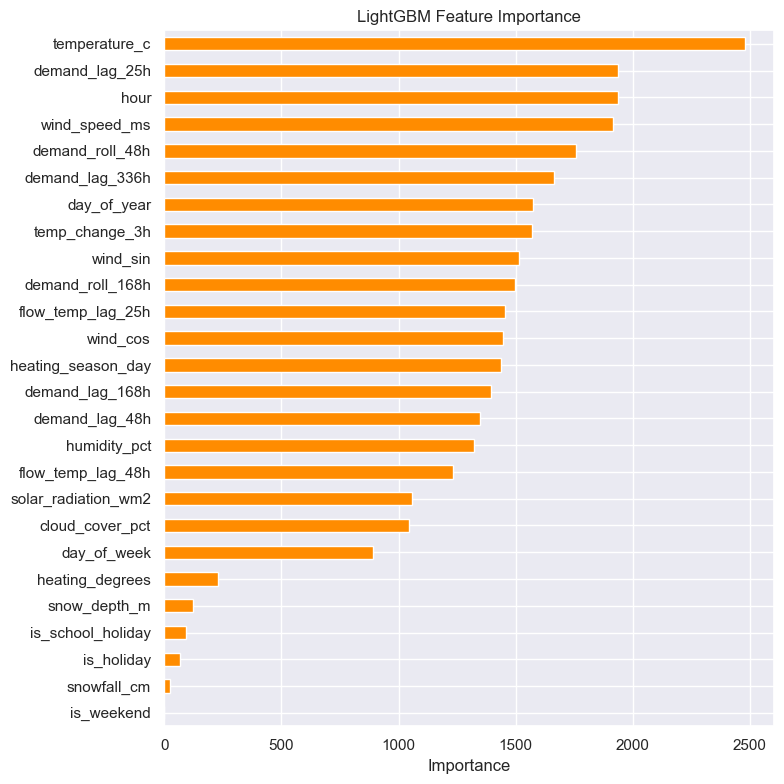

In [10]:
importance = pd.Series(lgb_mid.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
importance.plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('LightGBM Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()